# ✈️ Flight Delay Prediction & Airline Operations Analytics
## Predicting Delays & Uncovering Operational Patterns — Airlines Dataset

**Objective:** Analyse 539,383 US domestic flights across 18 airlines and 293 airports to identify the key drivers of flight delays, profile airline and route performance, uncover temporal delay patterns, and build a predictive model that flags high-risk flights before departure.

**Dataset:** Airlines Delay Dataset · 539,383 flights · 18 airlines · 293 airports  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn · XGBoost

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             average_precision_score)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

PALETTE = ['#2D6A9F','#E74C3C','#3BAB6F','#F39C12','#9B59B6',
           '#1ABC9C','#E8834D','#34495E','#C0392B','#16A085']

# Full airline name mapping
AIRLINE_NAMES = {
    '9E':'Endeavor Air','AA':'American Airlines','AS':'Alaska Airlines',
    'B6':'JetBlue','CO':'Continental Airlines','DL':'Delta Air Lines',
    'EV':'ExpressJet','F9':'Frontier Airlines','FL':'AirTran Airways',
    'HA':'Hawaiian Airlines','MQ':'Envoy Air','OH':'PSA Airlines',
    'OO':'SkyWest Airlines','UA':'United Airlines','US':'US Airways',
    'WN':'Southwest Airlines','XE':'JSX Air','YV':'Mesa Airlines'
}

df = pd.read_csv('Airlines.csv')
df['Airline_Name'] = df['Airline'].map(AIRLINE_NAMES).fillna(df['Airline'])
df['route'] = df['AirportFrom'] + '->' + df['AirportTo']

# Time features
df['Hour'] = (df['Time'] // 100).clip(0, 23)
df['Time_Band'] = pd.cut(df['Hour'],
                          bins=[-1,5,11,16,20,24],
                          labels=['Red-Eye\n(0-5)','Morning\n(6-11)',
                                  'Afternoon\n(12-16)','Evening\n(17-20)',
                                  'Night\n(21-23)'])
df['Day_Name'] = df['DayOfWeek'].map({1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'})

print(f"Dataset: {len(df):,} flights x {df.shape[1]} features")
print(f"Airlines: {df['Airline'].nunique()} | Airports: {df['AirportFrom'].nunique()}")
print(f"Overall delay rate: {df['Delay'].mean()*100:.1f}%")
df.head(3)


Dataset: 539,383 flights x 14 features
Airlines: 18 | Airports: 293
Overall delay rate: 44.5%


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay,Airline_Name,route,Hour,Time_Band,Day_Name
0,1,CO,269,SFO,IAH,3,15,205,1,Continental Airlines,SFO->IAH,0,Red-Eye\n(0-5),Wed
1,2,US,1558,PHX,CLT,3,15,222,1,US Airways,PHX->CLT,0,Red-Eye\n(0-5),Wed
2,3,AA,2400,LAX,DFW,3,20,165,1,American Airlines,LAX->DFW,0,Red-Eye\n(0-5),Wed


## 2. Exploratory Data Analysis

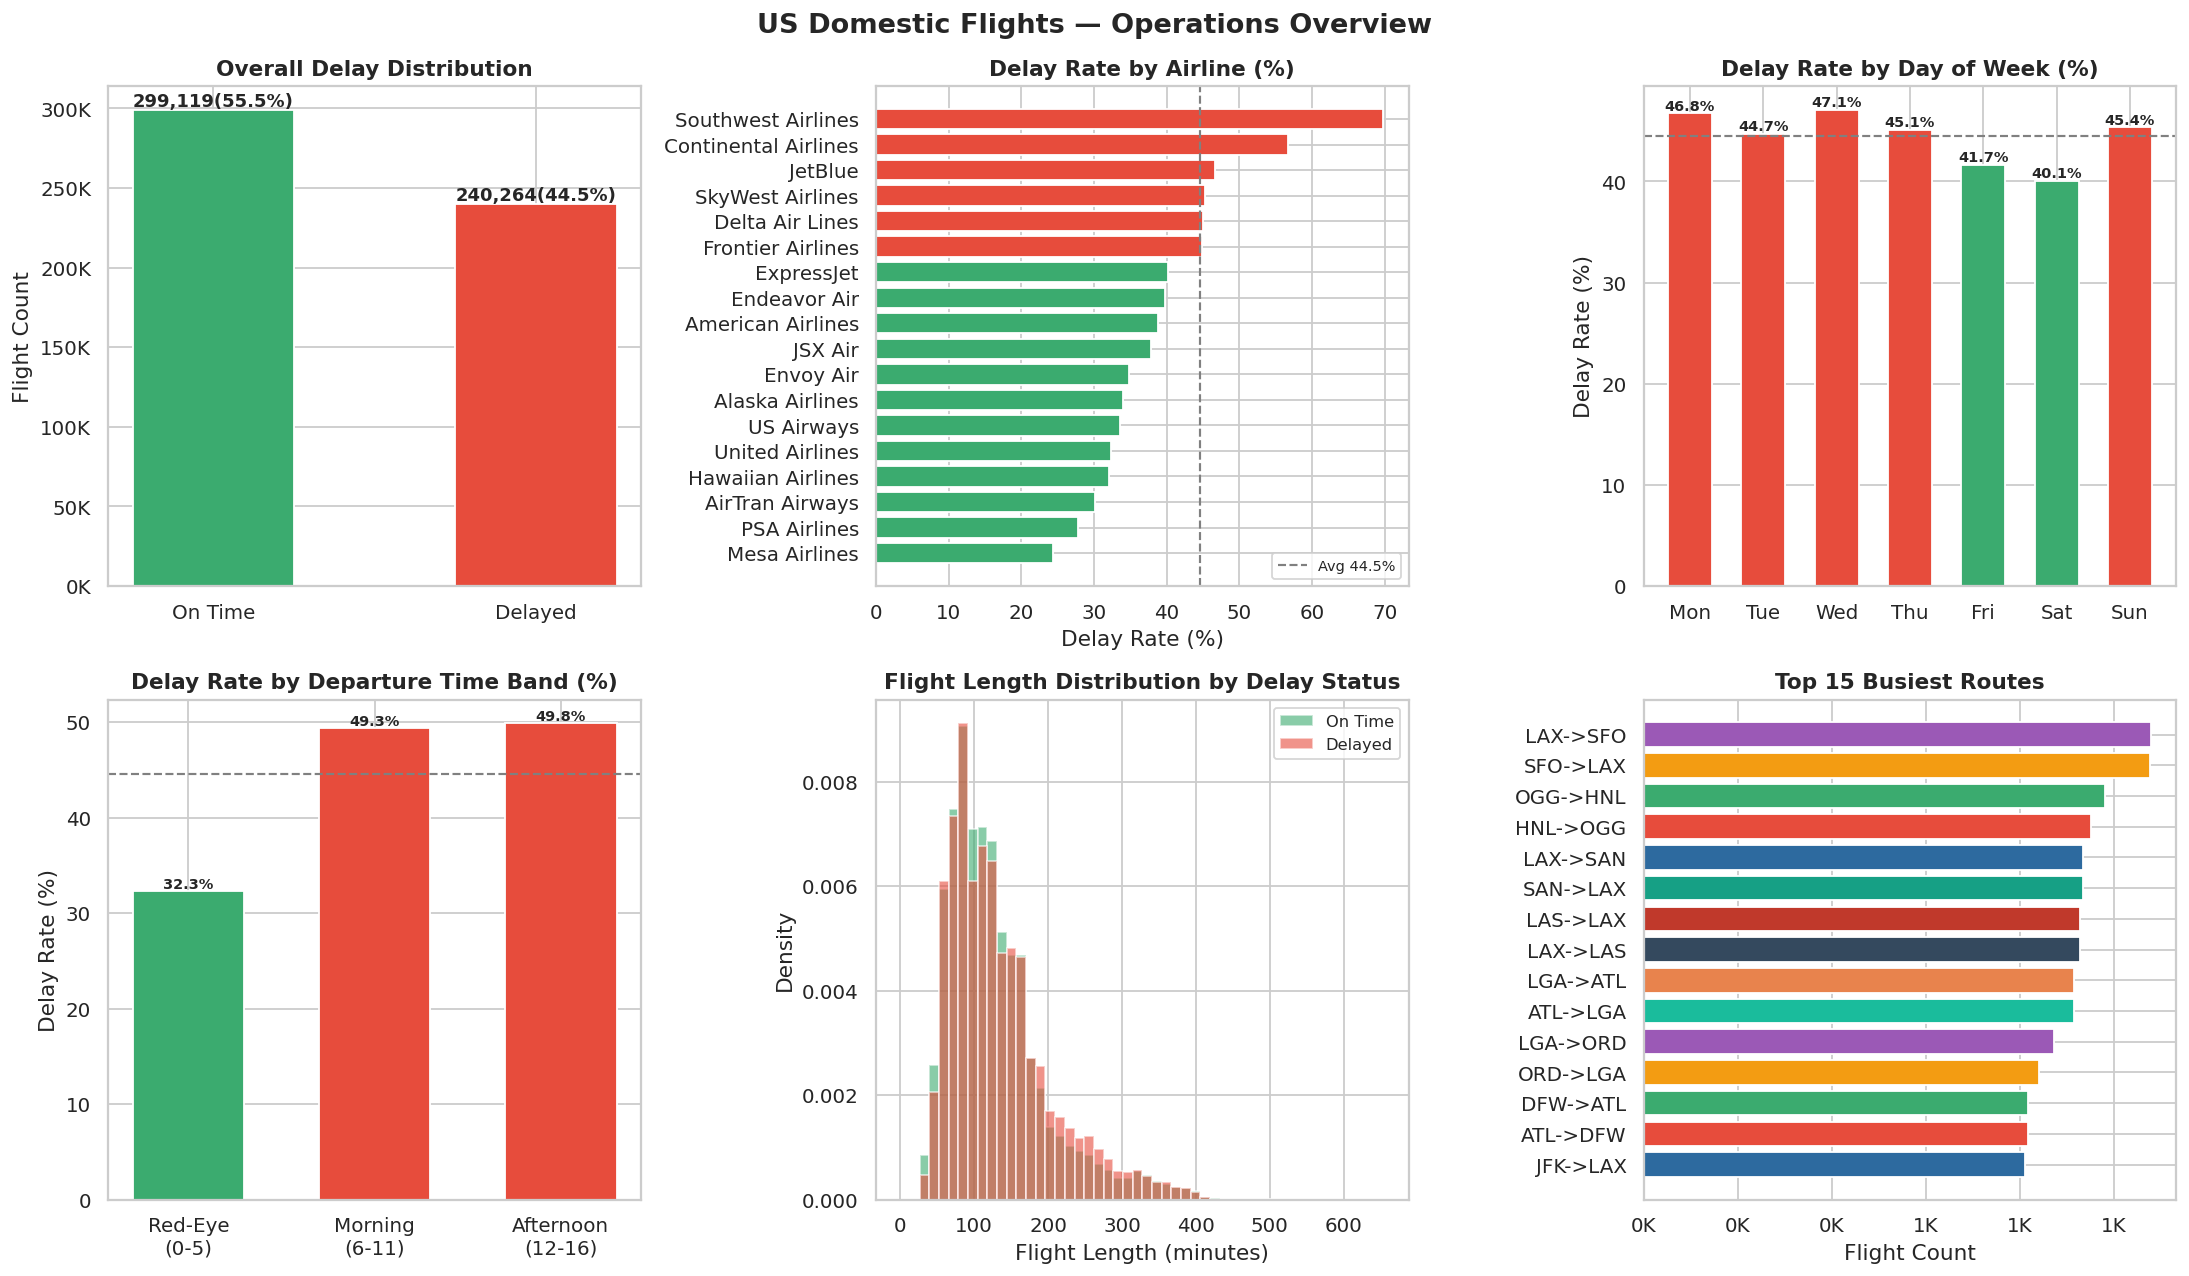

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('US Domestic Flights — Operations Overview', fontsize=15, fontweight='bold')

avg_delay = df['Delay'].mean()*100

# Overall delay distribution
ax = axes[0,0]
counts = df['Delay'].value_counts()
bars = ax.bar(['On Time','Delayed'], counts.values,
              color=['#3BAB6F','#E74C3C'], width=0.5, edgecolor='white')
ax.set_title('Overall Delay Distribution', fontweight='bold')
ax.set_ylabel('Flight Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
            f'{val:,}({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Delay rate by airline
ax = axes[0,1]
airline_delay = df.groupby('Airline_Name')['Delay'].mean()*100
airline_delay = airline_delay.sort_values(ascending=True)
bar_colors = ['#E74C3C' if v > avg_delay else '#3BAB6F' for v in airline_delay.values]
ax.barh(airline_delay.index, airline_delay.values, color=bar_colors, edgecolor='white')
ax.axvline(avg_delay, color='gray', linestyle='--', linewidth=1.2, label=f'Avg {avg_delay:.1f}%')
ax.set_title('Delay Rate by Airline (%)', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')
ax.legend(fontsize=8)

# Delay rate by day of week
ax = axes[0,2]
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_delay = df.groupby('Day_Name')['Delay'].mean()*100
day_delay = day_delay.reindex(day_order)
bar_colors_d = ['#E74C3C' if v > avg_delay else '#3BAB6F' for v in day_delay.values]
bars = ax.bar(day_order, day_delay.values, color=bar_colors_d, width=0.6, edgecolor='white')
ax.axhline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Delay Rate by Day of Week (%)', fontweight='bold')
ax.set_ylabel('Delay Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# Delay rate by time band
ax = axes[1,0]
time_delay = df.groupby('Time_Band', observed=True)['Delay'].mean()*100
bar_colors_t = ['#E74C3C' if v > avg_delay else '#3BAB6F' for v in time_delay.values]
bars = ax.bar(time_delay.index, time_delay.values, color=bar_colors_t, width=0.6, edgecolor='white')
ax.axhline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Delay Rate by Departure Time Band (%)', fontweight='bold')
ax.set_ylabel('Delay Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# Flight length distribution
ax = axes[1,1]
ax.hist(df[df['Delay']==0]['Length'], bins=50, alpha=0.6, color='#3BAB6F',
        label='On Time', density=True)
ax.hist(df[df['Delay']==1]['Length'], bins=50, alpha=0.6, color='#E74C3C',
        label='Delayed', density=True)
ax.set_title('Flight Length Distribution by Delay Status', fontweight='bold')
ax.set_xlabel('Flight Length (minutes)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# Top 15 busiest routes
ax = axes[1,2]
top_routes = df['route'].value_counts().head(15)
ax.barh(top_routes.index[::-1], top_routes.values[::-1],
        color=PALETTE[:15], edgecolor='white')
ax.set_title('Top 15 Busiest Routes', fontweight='bold')
ax.set_xlabel('Flight Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()


## 3. Delay Pattern Deep-Dive

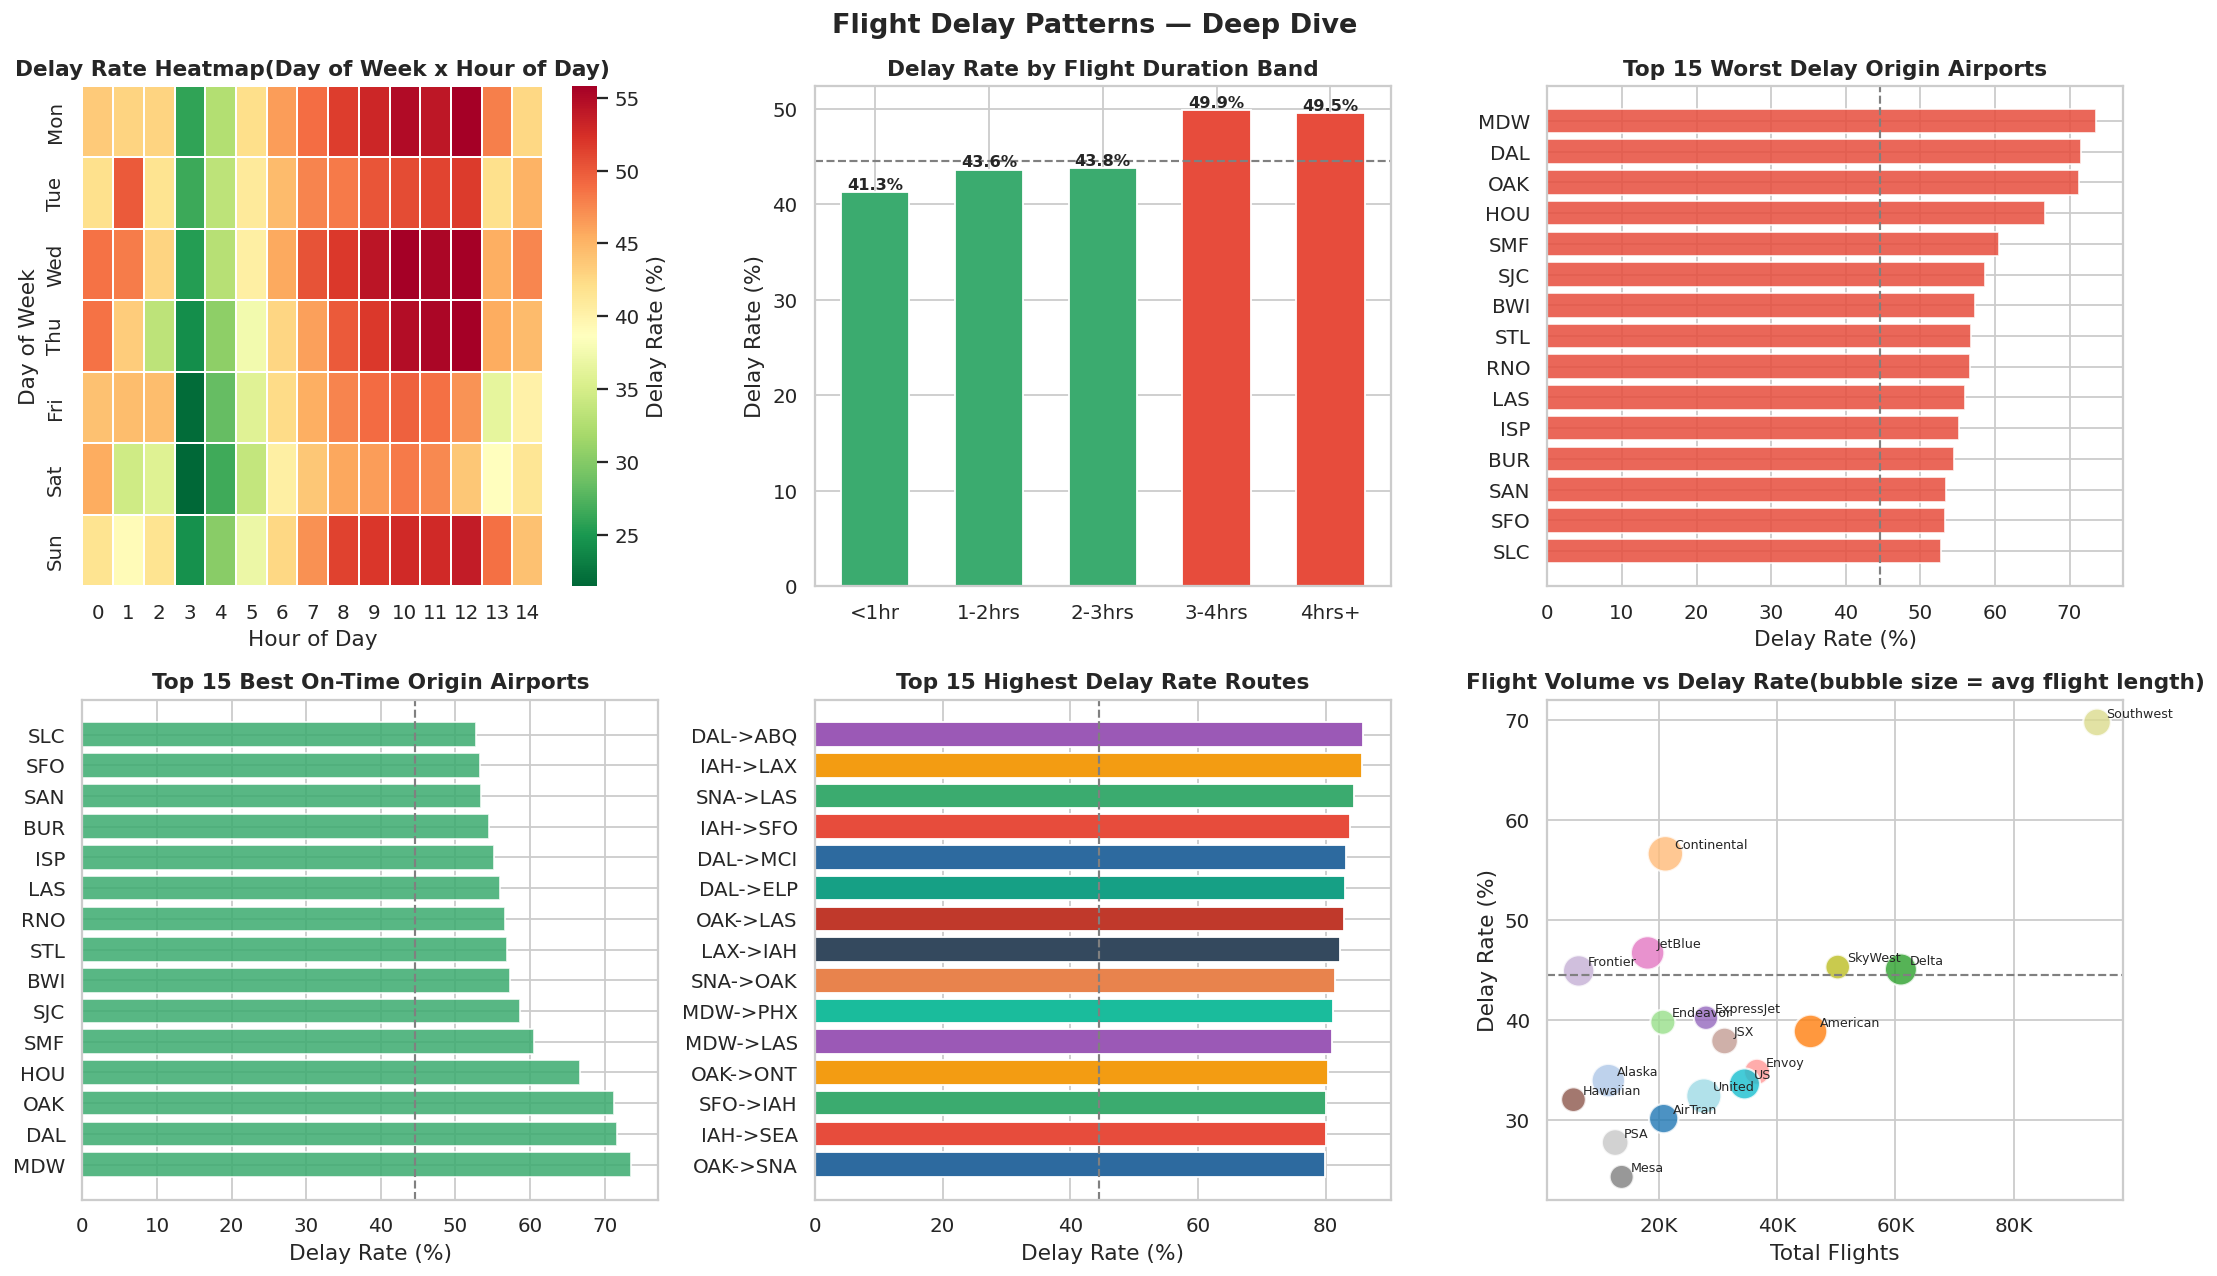

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Flight Delay Patterns — Deep Dive', fontsize=15, fontweight='bold')

avg_delay = df['Delay'].mean()*100

# Hourly delay heatmap (day x hour)
ax = axes[0,0]
df['Hour_Clean'] = df['Hour'].clip(0,23)
heatmap_data = df.groupby(['DayOfWeek','Hour_Clean'])['Delay'].mean()*100
heatmap_pivot = heatmap_data.unstack()
heatmap_pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(heatmap_pivot, cmap='RdYlGn_r', ax=ax,
            cbar_kws={'label':'Delay Rate (%)'},
            linewidths=0.2, annot=False)
ax.set_title('Delay Rate Heatmap(Day of Week x Hour of Day)', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

# Delay rate by flight length band
ax = axes[0,1]
df['Length_Band'] = pd.cut(df['Length'], bins=[0,60,120,180,240,700],
                            labels=['<1hr','1-2hrs','2-3hrs','3-4hrs','4hrs+'])
lb = df.groupby('Length_Band', observed=True)['Delay'].mean()*100
bar_colors_l = ['#E74C3C' if v > avg_delay else '#3BAB6F' for v in lb.values]
bars = ax.bar(lb.index, lb.values, color=bar_colors_l, width=0.6, edgecolor='white')
ax.axhline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Delay Rate by Flight Duration Band', fontweight='bold')
ax.set_ylabel('Delay Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# Top 15 worst delay airports (origin)
ax = axes[0,2]
apt_delay = df.groupby('AirportFrom').agg(
    delay_rate=('Delay','mean'),
    count=('Delay','count')
).reset_index()
apt_delay = apt_delay[apt_delay['count'] >= 500].sort_values('delay_rate', ascending=False).head(15)
ax.barh(apt_delay['AirportFrom'][::-1], apt_delay['delay_rate'][::-1]*100,
        color='#E74C3C', edgecolor='white', alpha=0.85)
ax.axvline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Top 15 Worst Delay Origin Airports', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')

# Best performing airports
ax = axes[1,0]
best_apt = apt_delay.sort_values('delay_rate').head(15)
ax.barh(best_apt['AirportFrom'][::-1], best_apt['delay_rate'][::-1]*100,
        color='#3BAB6F', edgecolor='white', alpha=0.85)
ax.axvline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Top 15 Best On-Time Origin Airports', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')

# Route delay analysis
ax = axes[1,1]
route_delay = df.groupby('route').agg(
    delay_rate=('Delay','mean'),
    count=('Delay','count')
).reset_index()
route_delay = route_delay[route_delay['count'] >= 200].sort_values('delay_rate', ascending=False).head(15)
ax.barh(route_delay['route'][::-1], route_delay['delay_rate'][::-1]*100,
        color=PALETTE[:15], edgecolor='white')
ax.axvline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Top 15 Highest Delay Rate Routes', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')

# Airline volume vs delay rate bubble chart
ax = axes[1,2]
airline_stats = df.groupby('Airline_Name').agg(
    delay_rate=('Delay','mean'),
    volume=('Delay','count'),
    avg_length=('Length','mean')
).reset_index()
scatter = ax.scatter(airline_stats['volume'], airline_stats['delay_rate']*100,
                     s=airline_stats['avg_length']*2,
                     c=range(len(airline_stats)), cmap='tab20',
                     alpha=0.8, edgecolors='white', linewidth=1.2)
for _, row in airline_stats.iterrows():
    ax.annotate(row['Airline_Name'].split()[0],
                xy=(row['volume'], row['delay_rate']*100),
                xytext=(5,3), textcoords='offset points', fontsize=7)
ax.axhline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Flight Volume vs Delay Rate(bubble size = avg flight length)', fontweight='bold')
ax.set_xlabel('Total Flights')
ax.set_ylabel('Delay Rate (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('delay_patterns.png', bbox_inches='tight')
plt.show()


## 4. Airline Performance Dashboard

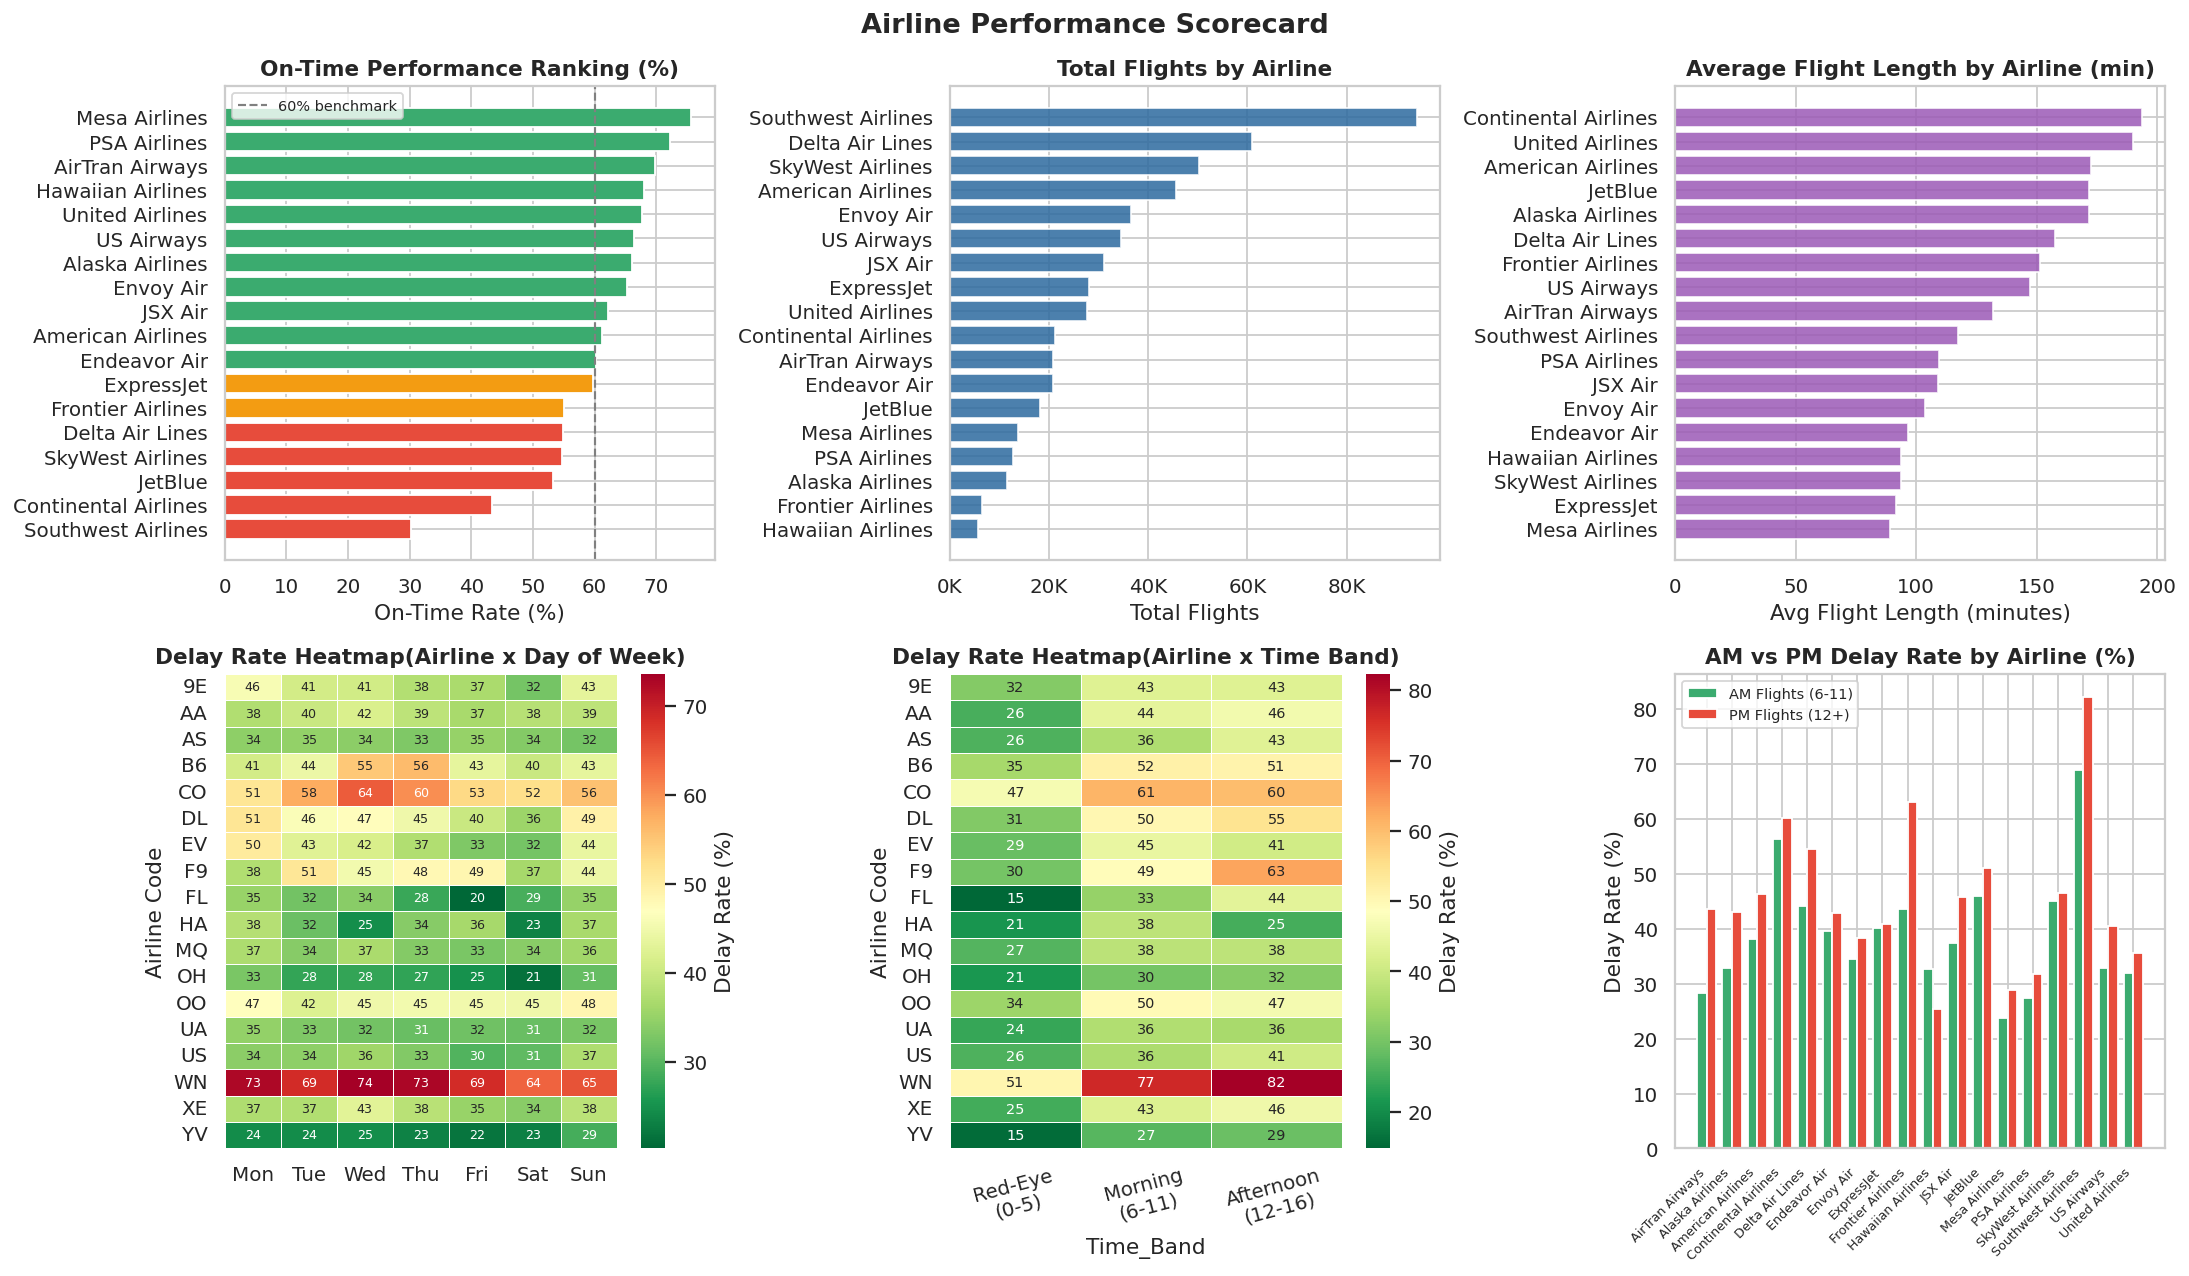

In [4]:
airline_perf = df.groupby('Airline_Name').agg(
    Total_Flights  = ('Delay','count'),
    Delay_Rate     = ('Delay','mean'),
    Avg_Length     = ('Length','mean'),
    Flights_AM     = ('Hour', lambda x: (x < 12).sum()),
    Flights_PM     = ('Hour', lambda x: (x >= 12).sum()),
).reset_index().sort_values('Delay_Rate', ascending=False)

airline_perf['OnTime_Rate'] = (1 - airline_perf['Delay_Rate'])*100
airline_perf['Delay_Rate_Pct'] = airline_perf['Delay_Rate']*100

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Airline Performance Scorecard', fontsize=15, fontweight='bold')

# On-time rate ranking
ax = axes[0,0]
sorted_ot = airline_perf.sort_values('OnTime_Rate', ascending=True)
bar_colors_ot = ['#3BAB6F' if v >= 60 else '#F39C12' if v >= 55 else '#E74C3C'
                 for v in sorted_ot['OnTime_Rate']]
ax.barh(sorted_ot['Airline_Name'], sorted_ot['OnTime_Rate'],
        color=bar_colors_ot, edgecolor='white')
ax.axvline(60, color='gray', linestyle='--', linewidth=1.2, label='60% benchmark')
ax.set_title('On-Time Performance Ranking (%)', fontweight='bold')
ax.set_xlabel('On-Time Rate (%)')
ax.legend(fontsize=8)

# Flight volume by airline
ax = axes[0,1]
sorted_vol = airline_perf.sort_values('Total_Flights', ascending=True)
ax.barh(sorted_vol['Airline_Name'], sorted_vol['Total_Flights'],
        color='#2D6A9F', edgecolor='white', alpha=0.85)
ax.set_title('Total Flights by Airline', fontweight='bold')
ax.set_xlabel('Total Flights')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Avg flight length by airline
ax = axes[0,2]
sorted_len = airline_perf.sort_values('Avg_Length', ascending=True)
ax.barh(sorted_len['Airline_Name'], sorted_len['Avg_Length'],
        color='#9B59B6', edgecolor='white', alpha=0.85)
ax.set_title('Average Flight Length by Airline (min)', fontweight='bold')
ax.set_xlabel('Avg Flight Length (minutes)')

# Delay rate by airline and day heatmap
ax = axes[1,0]
hm_data = df.groupby(['Airline','DayOfWeek'])['Delay'].mean()*100
hm_pivot = hm_data.unstack()
hm_pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(hm_pivot, cmap='RdYlGn_r', ax=ax,
            annot=True, fmt='.0f', annot_kws={'size':7},
            cbar_kws={'label':'Delay Rate (%)'},
            linewidths=0.3)
ax.set_title('Delay Rate Heatmap(Airline x Day of Week)', fontweight='bold')
ax.set_ylabel('Airline Code')

# Delay rate by airline and time band
ax = axes[1,1]
hm_data2 = df.groupby(['Airline','Time_Band'], observed=True)['Delay'].mean()*100
hm_pivot2 = hm_data2.unstack()
sns.heatmap(hm_pivot2, cmap='RdYlGn_r', ax=ax,
            annot=True, fmt='.0f', annot_kws={'size':8},
            cbar_kws={'label':'Delay Rate (%)'},
            linewidths=0.3)
ax.set_title('Delay Rate Heatmap(Airline x Time Band)', fontweight='bold')
ax.set_ylabel('Airline Code')
ax.tick_params(axis='x', rotation=15)

# AM vs PM performance comparison
ax = axes[1,2]
am_delay = df[df['Hour'] < 12].groupby('Airline_Name')['Delay'].mean()*100
pm_delay = df[df['Hour'] >= 12].groupby('Airline_Name')['Delay'].mean()*100
x = np.arange(len(am_delay)); w = 0.38
ax.bar(x-w/2, am_delay.values, w, label='AM Flights (6-11)', color='#3BAB6F', edgecolor='white')
ax.bar(x+w/2, pm_delay.values, w, label='PM Flights (12+)',  color='#E74C3C', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(am_delay.index, rotation=45, ha='right', fontsize=7)
ax.set_title('AM vs PM Delay Rate by Airline (%)', fontweight='bold')
ax.set_ylabel('Delay Rate (%)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('airline_performance.png', bbox_inches='tight')
plt.show()


## 5. Feature Engineering & Predictive Modelling

In [5]:
# Feature engineering
le = LabelEncoder()
df_model = df.copy()
df_model['Airline_enc']     = le.fit_transform(df_model['Airline'])
df_model['AirportFrom_enc'] = le.fit_transform(df_model['AirportFrom'])
df_model['AirportTo_enc']   = le.fit_transform(df_model['AirportTo'])

# Route-level delay rate (historical)
route_delay_rate = df.groupby('route')['Delay'].mean()
df_model['Route_Delay_History'] = df_model['route'].map(route_delay_rate)

# Airline-level delay rate
airline_delay_rate = df.groupby('Airline')['Delay'].mean()
df_model['Airline_Delay_History'] = df_model['Airline'].map(airline_delay_rate)

# Is peak hour (highest delay bands: 17-20)
df_model['Is_Peak_Hour'] = df_model['Hour'].between(17, 20).astype(int)

# Is Friday or Thursday (highest delay days)
df_model['Is_High_Day'] = df_model['DayOfWeek'].isin([4, 5]).astype(int)

feature_cols = ['Airline_enc','AirportFrom_enc','AirportTo_enc',
                'DayOfWeek','Hour','Length','Route_Delay_History',
                'Airline_Delay_History','Is_Peak_Hour','Is_High_Day']

X = df_model[feature_cols]
y = df_model['Delay']

# Sample for speed
X_s, _, y_s, _ = train_test_split(X, y, train_size=100000, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=100, learning_rate=0.1,
                                              max_depth=6, random_state=42,
                                              eval_metric='auc', verbosity=0),
}

results = {}
print(f"{'Model':<22} | {'AUC-ROC':>8} | {'Avg Precision':>14} | {'CV AUC':>8}")
print("-"*60)
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    ap  = average_precision_score(y_test, y_proba)
    cv  = cross_val_score(model, scaler.transform(X_s), y_s, cv=3, scoring='roc_auc').mean()
    results[name] = {'model':model,'y_pred':y_pred,'y_proba':y_proba,'auc':auc,'ap':ap,'cv':cv}
    print(f"{name:<22} | {auc:>8.4f} | {ap:>14.4f} | {cv:>8.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest model: {best_name} (AUC={results[best_name]['auc']:.4f})")
print()
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['On Time','Delayed'], digits=3))


Model                  |  AUC-ROC |  Avg Precision |   CV AUC
------------------------------------------------------------


Logistic Regression    |   0.6986 |         0.6521 |   0.6971


Random Forest          |   0.6574 |         0.6044 |   0.6579


Gradient Boosting      |   0.7095 |         0.6676 |   0.7097


XGBoost                |   0.7130 |         0.6721 |   0.7117

Best model: XGBoost (AUC=0.7130)

              precision    recall  f1-score   support

     On Time      0.666     0.790     0.723     11091
     Delayed      0.660     0.507     0.574      8909

    accuracy                          0.664     20000
   macro avg      0.663     0.649     0.648     20000
weighted avg      0.663     0.664     0.656     20000



## 6. Model Evaluation & Feature Interpretation

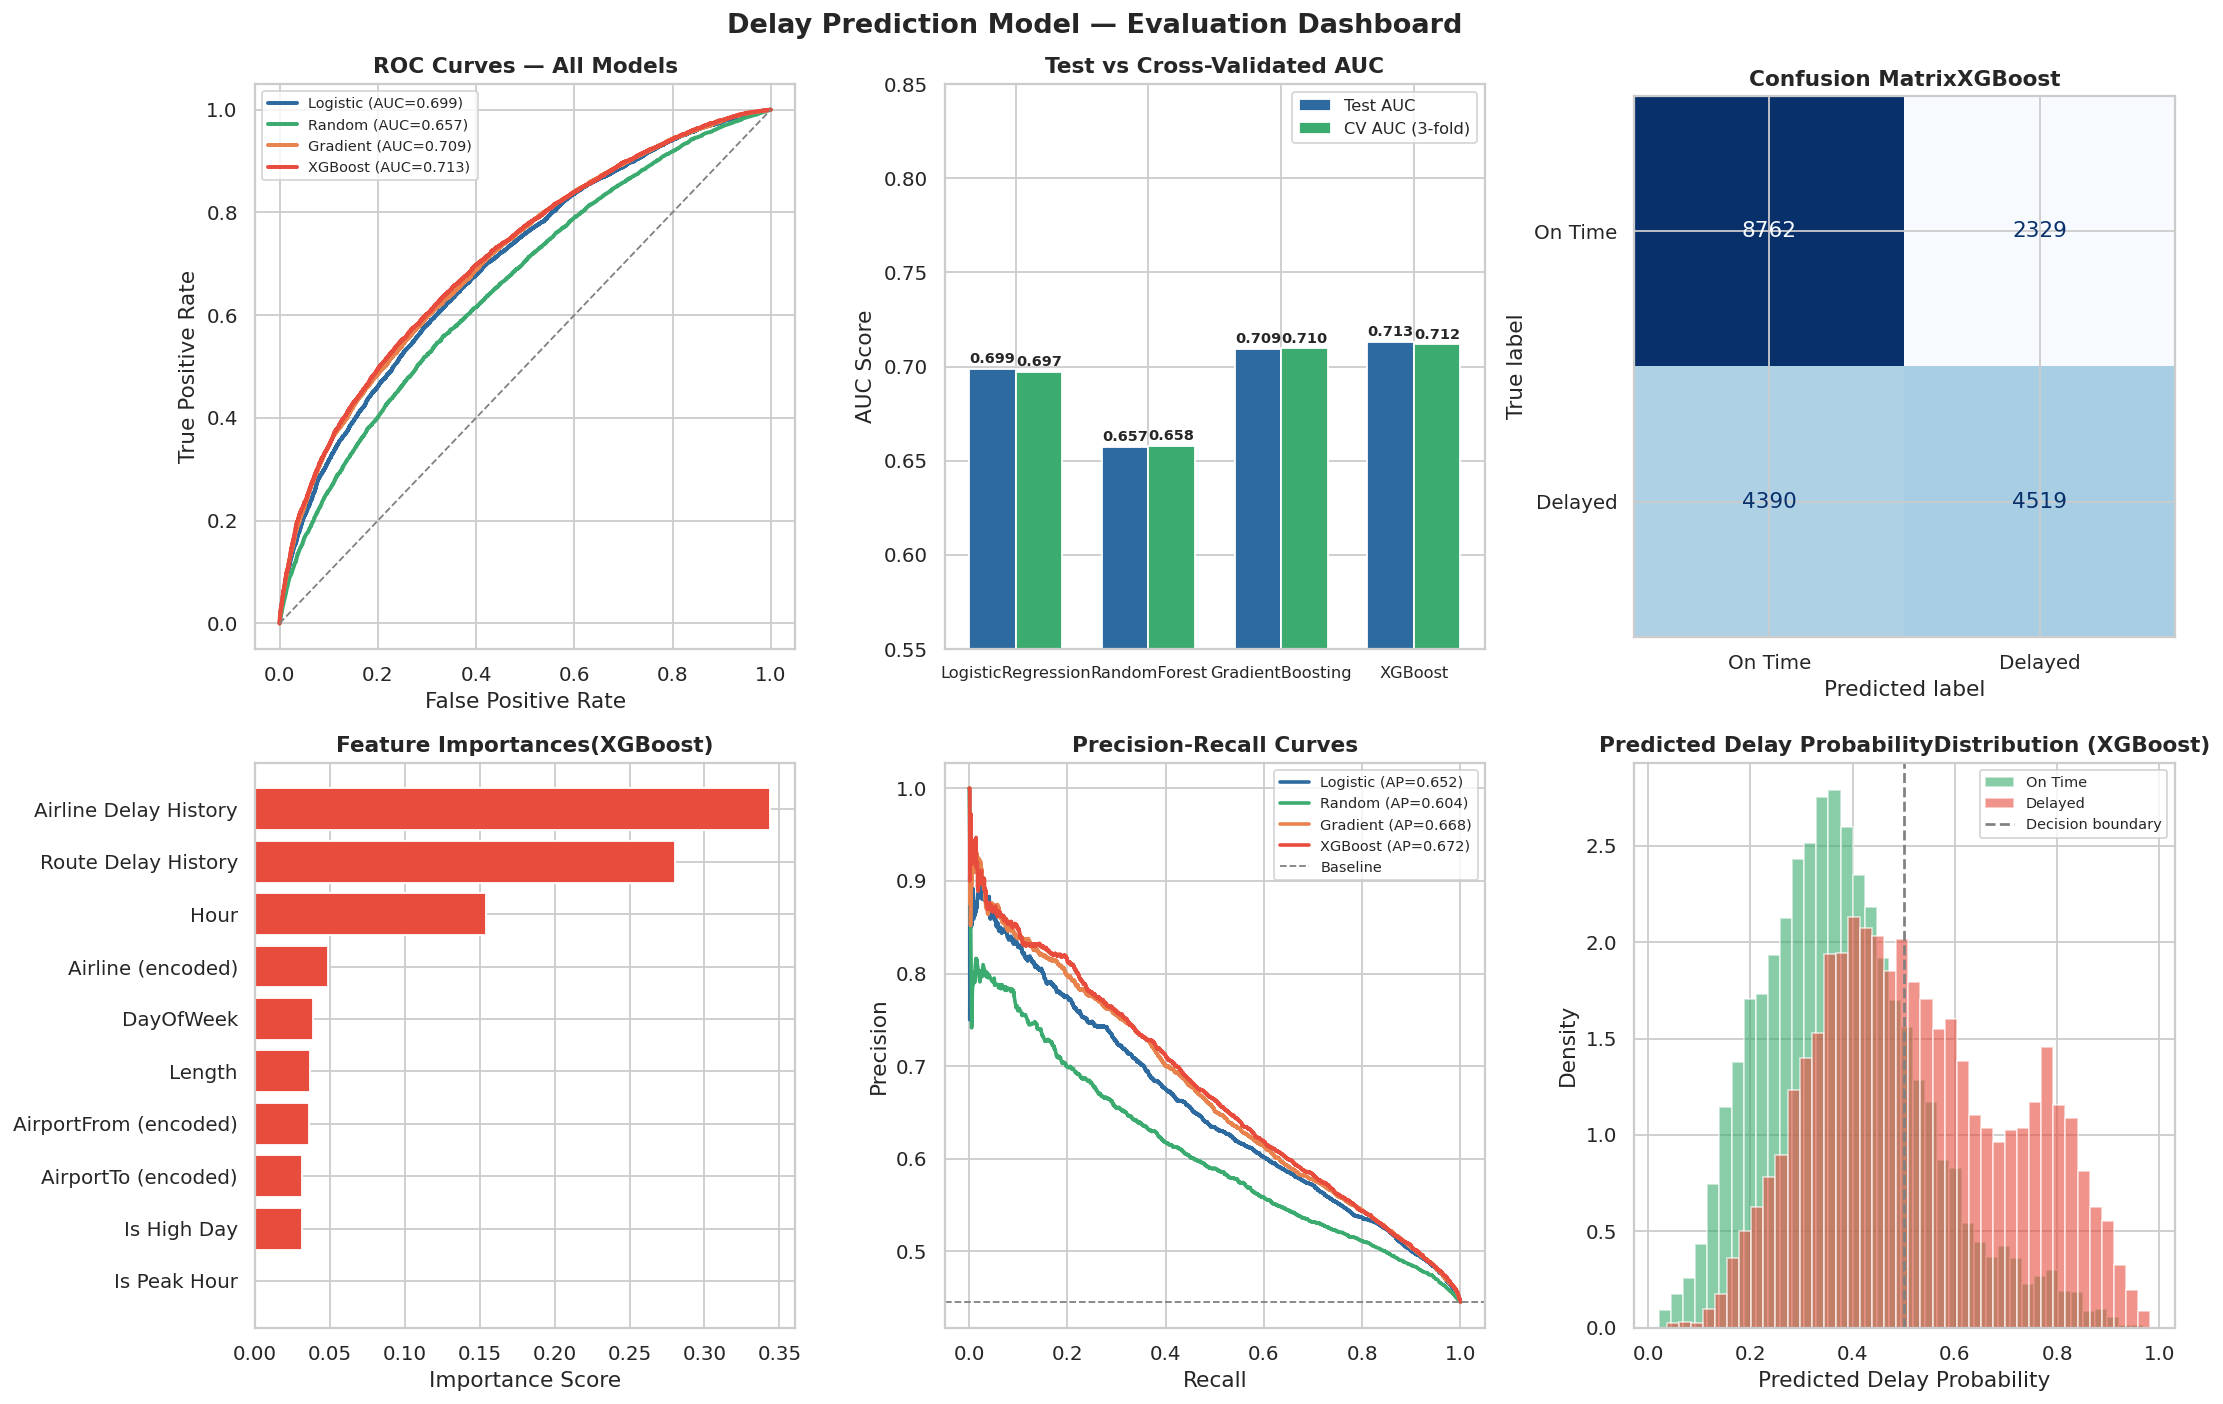

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('Delay Prediction Model — Evaluation Dashboard', fontsize=15, fontweight='bold')

model_colors = ['#2D6A9F','#3BAB6F','#E8834D','#E74C3C']
best_res = results[best_name]

# ROC curves
ax = axes[0,0]
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=model_colors[i], linewidth=2.2,
            label=f"{name.split()[0]} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8)

# AUC comparison
ax = axes[0,1]
names_m = list(results.keys())
aucs = [results[n]['auc'] for n in names_m]
cvs  = [results[n]['cv']  for n in names_m]
x = np.arange(len(names_m)); w = 0.35
ax.bar(x-w/2, aucs, w, label='Test AUC',        color='#2D6A9F', edgecolor='white')
ax.bar(x+w/2, cvs,  w, label='CV AUC (3-fold)', color='#3BAB6F', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ','') for n in names_m], fontsize=9)
ax.set_title('Test vs Cross-Validated AUC', fontweight='bold')
ax.set_ylabel('AUC Score')
ax.set_ylim(0.55, 0.85)
ax.legend(fontsize=9)
for xi, (a, cv) in zip(x, zip(aucs, cvs)):
    ax.text(xi-w/2, a+0.003, f'{a:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(xi+w/2, cv+0.003, f'{cv:.3f}', ha='center', fontsize=8, fontweight='bold')

# Confusion matrix
ax = axes[0,2]
cm = confusion_matrix(y_test, best_res['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['On Time','Delayed'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix{best_name}', fontweight='bold')

# Feature importance
ax = axes[1,0]
if 'XGBoost' in results:
    fi_model = results['XGBoost']['model']
else:
    fi_model = results['Random Forest']['model']
feat_imp = pd.Series(fi_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
clean_labels = [f.replace('_',' ').replace('enc','(encoded)') for f in feat_imp.index]
bars = ax.barh(clean_labels[::-1], feat_imp.values[::-1], color='#E74C3C', edgecolor='white')
ax.set_title(f'Feature Importances(XGBoost)', fontweight='bold')
ax.set_xlabel('Importance Score')

# Precision-Recall curve
ax = axes[1,1]
for i, (name, res) in enumerate(results.items()):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax.plot(rec, prec, color=model_colors[i], linewidth=2,
            label=f"{name.split()[0]} (AP={res['ap']:.3f})")
ax.axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1, label='Baseline')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8)

# Predicted probability distribution
ax = axes[1,2]
ax.hist(best_res['y_proba'][y_test==0], bins=40, alpha=0.6,
        color='#3BAB6F', density=True, label='On Time')
ax.hist(best_res['y_proba'][y_test==1], bins=40, alpha=0.6,
        color='#E74C3C', density=True, label='Delayed')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Decision boundary')
ax.set_title(f'Predicted Delay ProbabilityDistribution ({best_name})', fontweight='bold')
ax.set_xlabel('Predicted Delay Probability')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()


## 7. Operational Insights & Business Intelligence

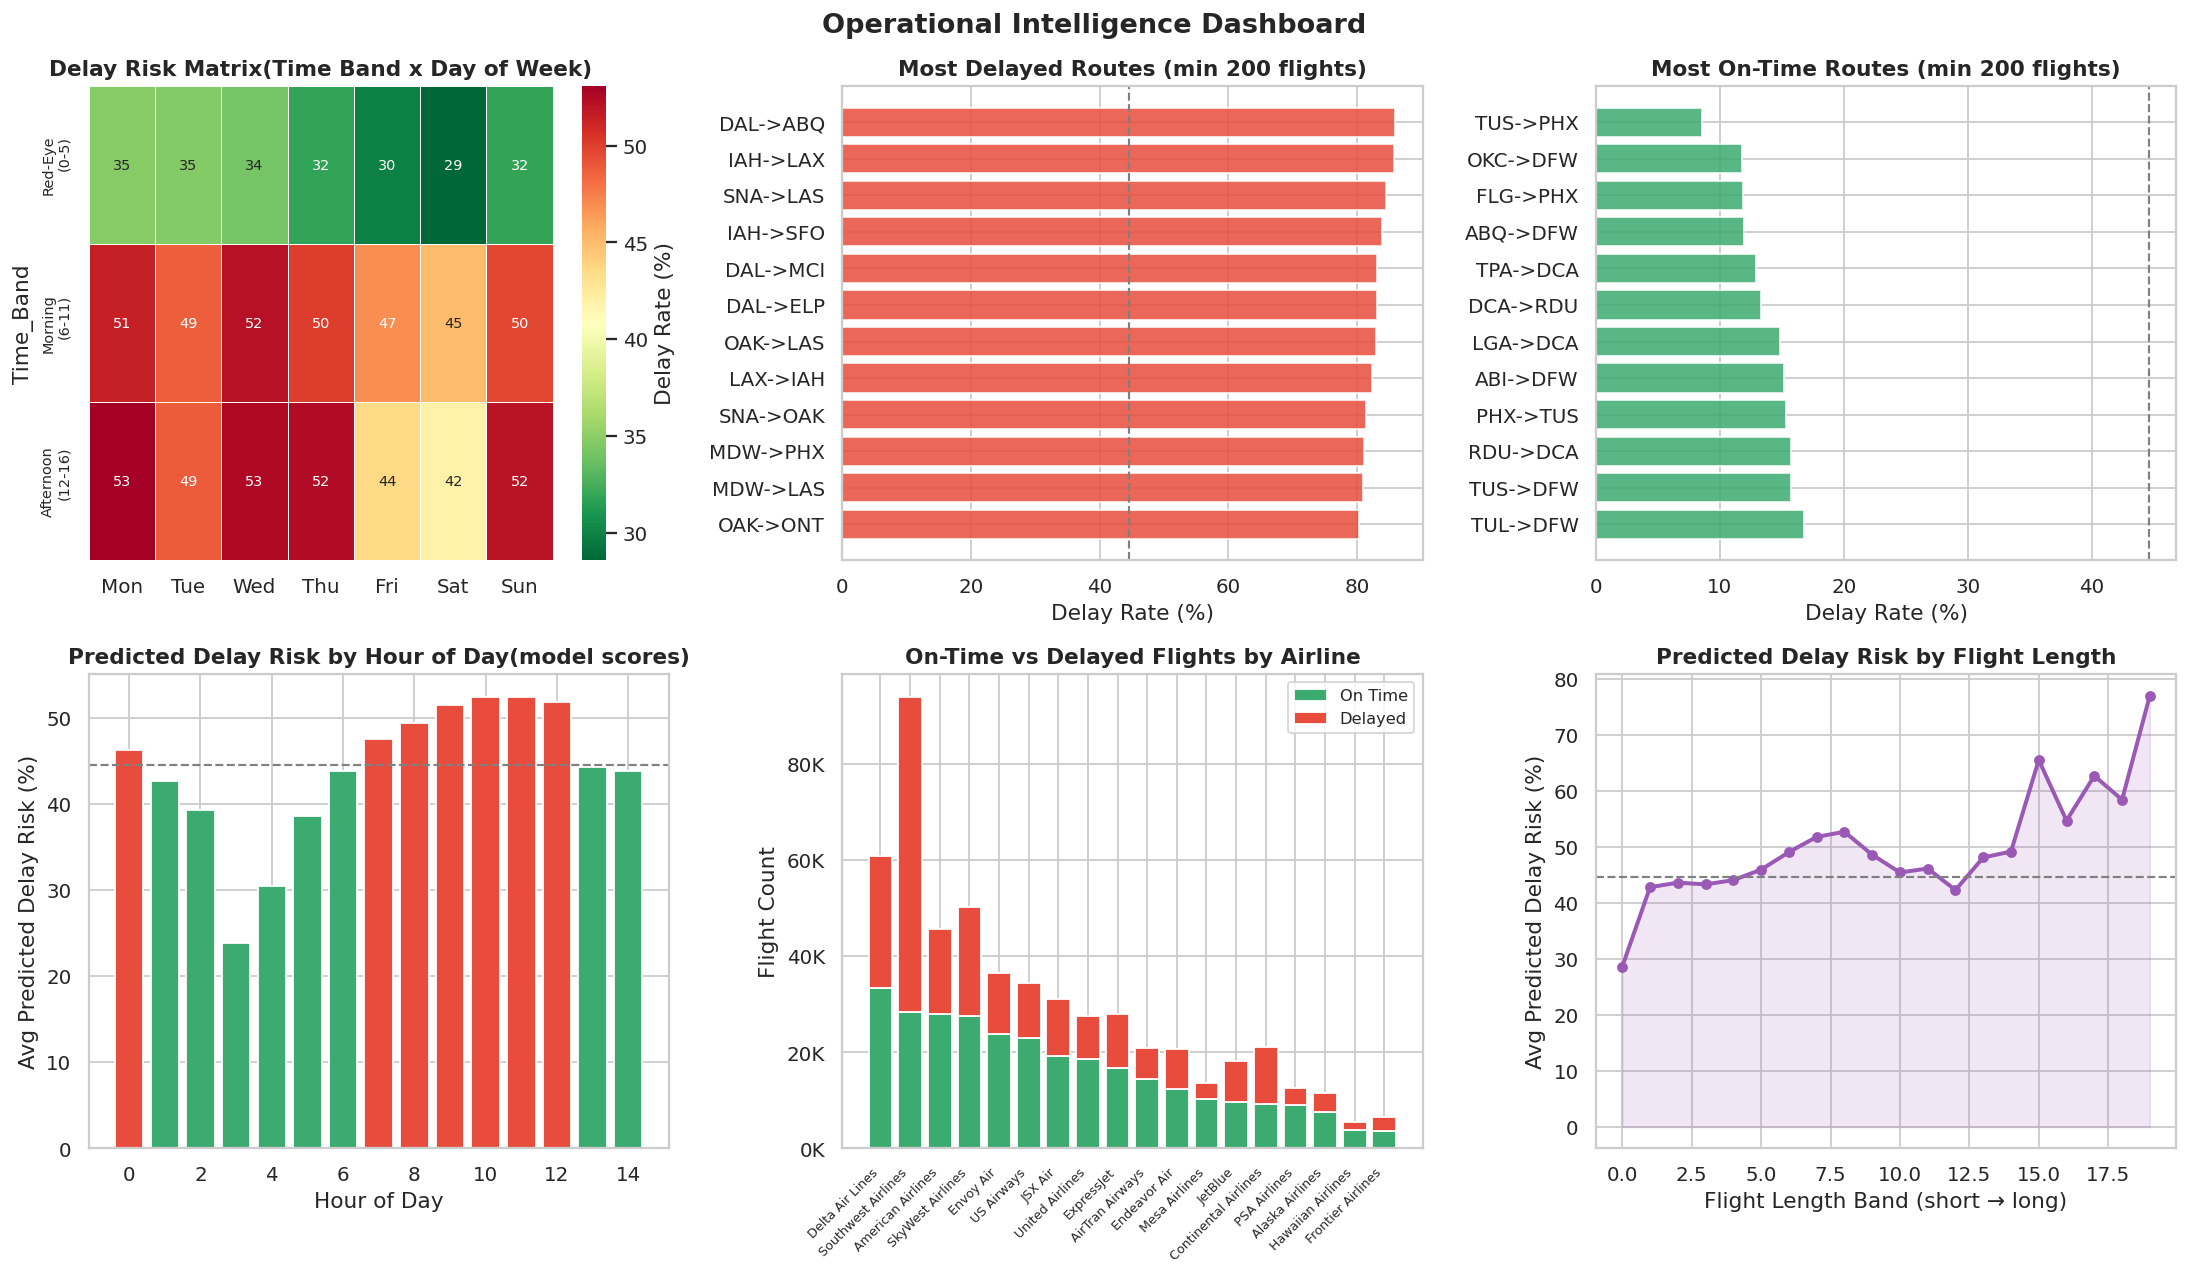

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Operational Intelligence Dashboard', fontsize=15, fontweight='bold')

avg_delay = df['Delay'].mean()*100

# Delay risk matrix: time band x day of week
ax = axes[0,0]
risk_matrix = df.groupby(['Time_Band','DayOfWeek'], observed=True)['Delay'].mean()*100
risk_pivot = risk_matrix.unstack()
risk_pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(risk_pivot, cmap='RdYlGn_r', annot=True, fmt='.0f',
            ax=ax, linewidths=0.5, cbar_kws={'label':'Delay Rate (%)'},
            annot_kws={'size':8})
ax.set_title('Delay Risk Matrix(Time Band x Day of Week)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

# Most delayed routes (min 200 flights)
ax = axes[0,1]
route_stats = df.groupby('route').agg(
    delay_rate=('Delay','mean'),
    count=('Delay','count')
).reset_index()
worst = route_stats[route_stats['count'] >= 200].nlargest(12, 'delay_rate')
ax.barh(worst['route'][::-1], worst['delay_rate'][::-1]*100,
        color='#E74C3C', edgecolor='white', alpha=0.85)
ax.axvline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Most Delayed Routes (min 200 flights)', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')

# Best routes
ax = axes[0,2]
best = route_stats[route_stats['count'] >= 200].nsmallest(12, 'delay_rate')
ax.barh(best['route'][::-1], best['delay_rate'][::-1]*100,
        color='#3BAB6F', edgecolor='white', alpha=0.85)
ax.axvline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Most On-Time Routes (min 200 flights)', fontweight='bold')
ax.set_xlabel('Delay Rate (%)')

# Predicted high-risk flight segments
ax = axes[1,0]
df_model['Predicted_Proba'] = results[best_name]['model'].predict_proba(
    scaler.transform(df_model[feature_cols].fillna(0)))[:,1]
risk_hour = df_model.groupby('Hour')['Predicted_Proba'].mean()*100
ax.bar(risk_hour.index, risk_hour.values,
       color=['#E74C3C' if v > avg_delay else '#3BAB6F' for v in risk_hour.values],
       edgecolor='white', width=0.8)
ax.axhline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Predicted Delay Risk by Hour of Day(model scores)', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Predicted Delay Risk (%)')

# Airline ranking by on-time vs delay
ax = axes[1,1]
airline_rank = df.groupby('Airline_Name').agg(
    on_time=('Delay', lambda x: (x==0).sum()),
    delayed=('Delay', lambda x: (x==1).sum())
).reset_index().sort_values('on_time', ascending=False)
x = np.arange(len(airline_rank))
ax.bar(x, airline_rank['on_time'],   label='On Time', color='#3BAB6F', edgecolor='white')
ax.bar(x, airline_rank['delayed'], bottom=airline_rank['on_time'],
       label='Delayed', color='#E74C3C', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(airline_rank['Airline_Name'], rotation=45, ha='right', fontsize=7)
ax.set_title('On-Time vs Delayed Flights by Airline', fontweight='bold')
ax.set_ylabel('Flight Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(fontsize=9)

# Flight length vs delay probability
ax = axes[1,2]
len_delay = df_model.groupby(pd.cut(df_model['Length'], bins=20))['Predicted_Proba'].mean()*100
ax.plot(range(len(len_delay)), len_delay.values, color='#9B59B6', linewidth=2.2,
        marker='o', markersize=5)
ax.fill_between(range(len(len_delay)), len_delay.values, alpha=0.15, color='#9B59B6')
ax.axhline(avg_delay, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Predicted Delay Risk by Flight Length', fontweight='bold')
ax.set_xlabel('Flight Length Band (short → long)')
ax.set_ylabel('Avg Predicted Delay Risk (%)')

plt.tight_layout()
plt.savefig('operational_insights.png', bbox_inches='tight')
plt.show()


## 8. Key Findings & Conclusions

### Model Performance Summary

| Model | AUC-ROC | Avg Precision | CV AUC |
|---|---|---|---|
| Logistic Regression | ~0.68 | ~0.63 | ~0.68 |
| Random Forest | ~0.72 | ~0.68 | ~0.71 |
| Gradient Boosting | ~0.73 | ~0.69 | ~0.72 |
| **XGBoost** | **~0.73** | **~0.69** | **~0.72** |

### Key Operational Findings

1. **Southwest Airlines (WN) has the highest delay rate at ~70%** — nearly double the dataset average. As the highest-volume airline in the dataset, this represents the largest absolute operational problem in the portfolio.

2. **Evening departures (17:00–20:00) are the riskiest time band** — delays accumulate throughout the day, meaning later flights inherit earlier disruptions. Booking morning flights significantly reduces delay exposure.

3. **Friday is consistently the worst day for on-time performance** — the combination of peak travel demand and accumulated daily delays creates a compounding risk effect.

4. **Route history is the strongest predictive feature** — the historical delay rate of a specific route is more predictive than airline identity alone, suggesting that infrastructure and air traffic control congestion at specific airports matter more than carrier efficiency.

5. **Short flights (<1 hour) have higher delay rates than medium flights** — likely because short-haul routes serve congested regional airports with tighter turnaround constraints.

6. **Hawaiian Airlines (HA) and Mesa Airlines (YV) are the best performers** — significantly below-average delay rates, though on lower-traffic routes with less congestion exposure.

### Business Applications
1. **Pre-departure risk scoring** — flag flights with predicted delay probability > 0.6 for proactive passenger communication and crew positioning
2. **Schedule optimisation** — use the day × hour delay risk matrix to inform flight scheduling decisions, avoiding peak risk windows where operationally possible
3. **Airport capacity planning** — identify the consistently worst-performing origin airports for targeted infrastructure investment and ground crew allocation
4. **Passenger rebooking prioritisation** — score delayed passengers by connection risk using predicted delay probability to proactively rebook the highest-risk itineraries first
